setup:
- please make sure that mochi_class is the first classy instance avialble on PATH
- this tutorial should be used with the 292-mochi-class branch of cloelib

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.mochi_class_cosmology import mochiCLASSBackground, mochiCLASSLinearPerturbations, mochiCLASSNonLinearPerturbations # requires cloelib branch 292-mochi-class
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations
from cloelib.cosmology.jax_cosmology import JAXBackground, JAXLinearPerturbations, JAXNonLinearPerturbations
from cloelib.cosmology.cosmology import Background

# Validation benchmark in astropy
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# mochi_class only

In [2]:
# import stable parameters from file
# mochi - cubic galileon
# use the lna array from this example for our stable basis too
lna_smg_gal, Delta_Mpl_gal, Dkin_gal, cs2_gal = np.loadtxt("cubic_galileon_stable_params_mathematica.dat", unpack=True)
lna_de_gal, rho_de_gal = np.loadtxt("rho_de_stable_cubic_galileon_mathematica.dat", unpack=True, dtype=float)
alpha_B0_gal =  1.380051990990777

Text(0.5, 1.0, 'CLASS Perturbations')

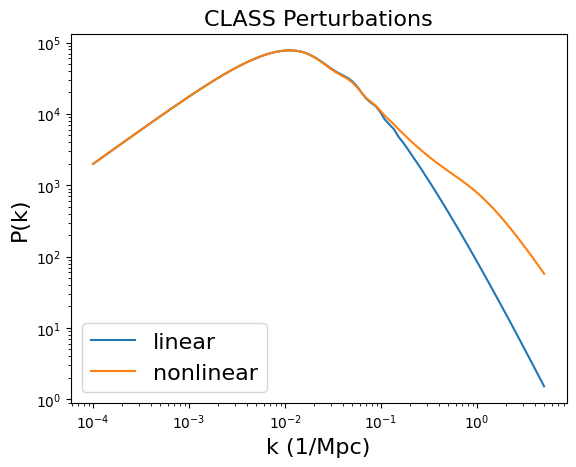

In [3]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
Omega_cdm0 = omch2/h**2
ombh2 = 0.022
Omega_b0 = ombh2/h**2
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.96
mnu = 0.
As=2e-9

# z-array
z = np.linspace(0, 3, 100)

stable_MG_dict = {
    "w0": w,
    "wa": wa, 
    "lna_smg": lna_de_gal, # same lna spacing as in ,mochi_class example files
}

# background
class_instance = mochiCLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                                Omega_k0=Omega_k0,
                                As=As, ns=ns, mnu=0., #w0=-1.0, wa=0.0, 
                                N_mnu=0,
                                mg_stable_basis_on=False,
                                mg_background_model='wowa',
                                stable_MG_dict = stable_MG_dict,
                                )
H_z_class = class_instance.hubble_parameter(z)
chi_z_class = class_instance.comoving_distance(z)
dA_z_class = class_instance.angular_diameter_distance(z)
tr_z_class = class_instance.transverse_comoving_distance(z)

# perturbations
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)

# CLASS PERTURBATIONS
# k-array
class_linear = mochiCLASSLinearPerturbations(background=class_instance, redshifts=z)
class_nonlinear = mochiCLASSNonLinearPerturbations(background=class_instance, 
                                              redshifts=z, 
                                              nonlinear_model='hmcode16')
linear_pk_class = class_linear.matter_power_spectrum(z, ks)
nonlinear_pk_class = class_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_class[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_class[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CLASS Perturbations", fontsize = 16)


In [4]:
class_instance.get_background()

{'z': array([1.00000000e+14, 9.89308584e+13, 9.78731474e+13, ...,
        2.17307062e-02, 1.08069579e-02, 0.00000000e+00]),
 'proper time [Gyr]': array([7.55951851e-26, 7.72379221e-26, 7.89163568e-26, ...,
        1.34848023e+01, 1.36388707e+01, 1.37937282e+01]),
 'conf. time [Mpc]': array([4.63478500e-09, 4.68571670e-09, 4.73664841e-09, ...,
        1.40798394e+04, 1.41278448e+04, 1.41755802e+04]),
 'H [1/Mpc]': array([2.15725629e+22, 2.11137463e+22, 2.06646880e+22, ...,
        2.28142397e-04, 2.26966907e-04, 2.25822893e-04]),
 'comov. dist.': array([14175.58020335, 14175.58020335, 14175.58020335, ...,
           95.74080862,    47.73542064,     0.        ]),
 'ang.diam.dist.': array([1.41755802e-10, 1.43287751e-10, 1.44836256e-10, ...,
        9.37045427e+01, 4.72250614e+01, 0.00000000e+00]),
 'lum. dist.': array([1.41755802e+18, 1.40240232e+18, 1.38740865e+18, ...,
        9.78213240e+01, 4.82512953e+01, 0.00000000e+00]),
 'comov.snd.hrz.': array([2.67631746e-09, 2.70524032e-09, 2.

In [4]:
class_instance.Om_smg(z)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## stable basis prameterisation (Lombriser+ 2019) in mochiclass

In [ ]:

#################################################
# compute cosmo mochi class
#################################################

def Compute_mochi_cosmo(compute_spectra=True, # if false only background
                        background_model='wowa', # others are 'lcdm' and 'rho_de'
                        mg_stable_basis_on=True, # if false no modified gravity
                        w0=-1., wa=0., # for wowa background
                        ob= 0.0224, oc=0.0122, h=0.67, n_s=0.96, A_s=2e-9,
                        lna_de=None, rho_de=None, # for rho_de background
                        lna_smg=None, # always need to load lna, even if no MG used (apart from lcdm)
                        Delta_Mpl=None,Dkin=None,cs2=None, alpha_B0=None, 
                        print_comments=False,
                        ):
    ''' 
    run mochi for setting in fixed_parameters_linus.py
    NEED TO LOAD FILE FIXED_PARAMETERS_LINUS.PY
    - choose background_model
    - choose if spectra are needed
    - choose if MG is switched on (stable basis)
    '''
    # reset CLASS if object already exists
    if 'cosmo' in locals():
        cosmo.struct_cleanup()
        cosmo.empty() 
    

    cosmo = Class()
    # if background_model == 'lcdm':
    #     cosmo.set(file_standard_params_planck) # LCDM planck values cosmo constants
    # else:
    cosmo_params = {
                'h': h, 
            #    'theta_s_100' : 1.041783, # alternative to h, better, cause it keeps CMB fixed
                'YHe': 0.24,
                'omega_b': ob,
                'omega_cdm': oc,
                'N_ur': 3.044,
                'n_s': n_s,
                'A_s': A_s
                }

    cosmo.set(cosmo_params) # LCDM values cosmo constants - canbe modified from planck values
    cosmo.set(file_precision_params) # precision parameters

    # check if spectra are needed
    if compute_spectra:
        # load spectra settings
        cosmo.set(file_common_spectra_settings)

    ############## specify Omegas for MG/non-MG before defining background #############
    # ----------------------------
    # ----> background parameters:
    # ----------------------------
    # 1a) Omega_smg is the fractional density of the scalar field today. There are three possibilities
    #     i)    Omega_smg unspecified or equivalently set to 0. In this case the code will
    #           ignore the scalar field equations and will use the standard CLASS equations
    #     ii)   Omega_smg has a value larger than 0 but smaller than 1. In this case you should
    #           leave either Omega_Lambda or Omega_fld unspecified. Then, hi_class will run# default: no
    #           with the scalar field equations, and Omega_Lambda or Omega_fld will be inferred
    #           using the closure equation (sum_i Omega_i) equals (1 + Omega_k)
    #     iii)  Omega_smg has a negqative value. In this case the equations for the scalar field
    #           will be used, you have to specify both Omega_Lambda and Omega_fld, and Omega_smg will
    #           be inferred by the code using the closure equation
    #     (see the "explanatory.ini" file for details on perfect fluid options)


    # convert alpha_B0 input type
    if mg_stable_basis_on:
        if isinstance(alpha_B0, np.ndarray):
            # convert array to float
            alpha_B0_str = np.array2string(alpha_B0, separator=',', precision=16).replace('\n','').strip('[]')
        elif isinstance(alpha_B0, (int, float, np.number)):
            # convert to string
            alpha_B0_str = str(alpha_B0)
        else:
            raise ValueError("alpha_B0 must be a number or a 1D array")


    ############## LCDM ##############
    if background_model == 'lcdm':

        if mg_stable_basis_on: # with MG
            mochiclass_params_mg_lcdm = {
                    # omega settings here assume that MG (stable basis) is loaded
                    'Omega_Lambda': 0., 
                    'Omega_fld': 0.,
                    'Omega_smg': -1., # fractional density scalar field today (0: no smg, negative: specify both Omega_Lambda and Omega_fld, infer Omega_smg, 0<...<1: specify both Omega_Lambda and Omega_smg, infer Omega_fld)
                    'expansion_model': 'lcdm',
                    'lna_smg': np.array2string(lna_smg, separator=',', precision=16).replace('\n','').strip('[]'),
                    'Delta_M2': np.array2string(Delta_Mpl, separator=',', precision=16).replace('\n','').strip('[]'),
                    'D_kin': np.array2string(Dkin, separator=',', precision=16).replace('\n','').strip('[]'),
                    'cs2': np.array2string(cs2, separator=',', precision=16).replace('\n','').strip('[]'),
                    'parameters_smg': alpha_B0_str,
                }
            cosmo.set(file_mochiclass_params_stable_general) # stable params general settings
            cosmo.set(mochiclass_params_mg_lcdm) # stable params for MG

        else: # no MG
            mochiclass_params_background_lcdm = {
                    'Omega_fld': 0.,
                    'Omega_smg': 0.,
                }
            cosmo.set(mochiclass_params_background_lcdm)


    ############## wowa ##############
    elif background_model == 'wowa':

        if mg_stable_basis_on: # wowa setting swith MG same as DESI
            mochiclass_wowa_stable_basis = { 
                    # omega settings here assume that MG (stable basis) is loaded
                    'Omega_Lambda': 0.,
                    'Omega_fld': 0.,
                    'Omega_smg': -1., # fractional density scalar field today (0: no smg, negative: specify both Omega_Lambda and Omega_fld, infer Omega_smg, 0<...<1: 
                    'expansion_model': 'wowa',
                    'expansion_smg': np.array2string(np.array([0.5, w0, wa]), separator=',', precision=16).replace('\n','').strip('[]'), # for wowa: expansion_smg = Omega_smg, w0, wa
                    'lna_smg': np.array2string(lna_smg, separator=',', precision=16).replace('\n','').strip('[]'),
                    'Delta_M2': np.array2string(Delta_Mpl, separator=',', precision=16).replace('\n','').strip('[]'),
                    'D_kin': np.array2string(Dkin, separator=',', precision=16).replace('\n','').strip('[]'),
                    'cs2': np.array2string(cs2, separator=',', precision=16).replace('\n','').strip('[]'),
                    'parameters_smg': alpha_B0_str,
                }
            cosmo.set(file_mochiclass_params_stable_general) # stable params
            cosmo.set(mochiclass_wowa_stable_basis) # stable params for wowa

        else: # wowa without MG
            mochiclass_params_wowa= {
                'Omega_Lambda': 0, 
                #'Omega_fld': 
                #'Omega_scf': 0,
                'Omega_smg': 0,
                'use_ppf': 'yes',
                'c_gamma_over_c_fld': 0.4,
                'fluid_equation_of_state': 'CLP',
                'w0_fld': w0,
                'wa_fld': wa,
                'cs2_fld': 1
                }
            cosmo.set(mochiclass_params_wowa) # no mg

        
    ############## rho_de ##############
    elif background_model == 'rho_de':
        # load background rho_de
        mochiclass_params_background_rhoDE = {
                            # omega settings for mochi stable basis and rho_de background
                            'Omega_Lambda': 0.,
                            'Omega_fld': 0.,
                            'Omega_smg': -1., # fractional density sclar field today (0: no smg, negative: specify both Omega_Lambda and Omega_fld, infer Omega_smg, 0<...<1: specify both Omega_Lambda and Omega_smg, infer Omega_fld)
                            'expansion_model': 'rho_de',
                            'expansion_smg': 0.5,
                            'lna_de': np.array2string(lna_de, separator=',', precision=16).replace('\n','').strip('[]'),
                            'de_evo': np.array2string(rho_de, separator=',', precision=16).replace('\n','').strip('[]'),
                }
        cosmo.set(mochiclass_params_background_rhoDE)

        # for perturbations
        if mg_stable_basis_on==False: # no MG (actiavte stable basis, but LCDM values)
            if print_comments:
                print('MG switched off, but actually using stable basis with LCDM values for basis functions')
            mochiclass_params_stable_basisfcts = { 
                        'lna_smg': np.array2string(lna_smg, separator=',', precision=16).replace('\n','').strip('[]'),
                        'Delta_M2': np.array2string(np.zeros_like(lna_smg), separator=',', precision=16).replace('\n','').strip('[]'),
                        'D_kin': np.array2string(np.ones_like(lna_smg)*1e-8, separator=',', precision=16).replace('\n','').strip('[]'),
                        'cs2': np.array2string(np.ones_like(lna_smg), separator=',', precision=16).replace('\n','').strip('[]'),
                        'parameters_smg': '0.0',
                    }
            cosmo.set(file_mochiclass_params_stable_general) # stable params
            cosmo.set(mochiclass_params_stable_basisfcts)

        if mg_stable_basis_on: 
            mochiclass_params_stable_basisfcts = { 
                    'lna_smg': np.array2string(lna_smg, separator=',', precision=16).replace('\n','').strip('[]'),
                    'Delta_M2': np.array2string(Delta_Mpl, separator=',', precision=16).replace('\n','').strip('[]'),
                    'D_kin': np.array2string(Dkin, separator=',', precision=16).replace('\n','').strip('[]'),
                    'cs2': np.array2string(cs2, separator=',', precision=16).replace('\n','').strip('[]'),
                    'parameters_smg': alpha_B0_str,
                }
            cosmo.set(file_mochiclass_params_stable_general) # stable params
            cosmo.set(mochiclass_params_stable_basisfcts)


    else:
        raise ValueError("background_model must be 'lcdm', 'rho_de' or 'wowa'")

    if compute_spectra:
        cosmo.set(file_spectra_params)

    # compute
    try:
        cosmo.compute()
        if print_comments:
            print('cosmo class computed succesfully')
    except CosmoComputationError as e:
        print(f"Computation error: {e}")
        raise
    except CosmoSevereError as e:
        print(f"Computation error: {e}")
        raise

    return cosmo



def Solve_M2_ODE(lna_array, H, rho_phi, Omega_DE,
                 Dkin, cs2, b, M2_init = 1., M2D_init = 0., w0=-1,wa=0,print_comments=False):
    '''
    solve ODE for M2 (= M^2) numerically
    M2'' + r (M2')^2/M2 + p M2' + q M2 = g
    with r,p,q,g as functions of x=lna
    solve forward, initioal conditions at lna=-5
    '''

    # H_dot = dH/dlna
    H_spline = UnivariateSpline(lna_array, H, s=0)
    H_dot = H_spline.derivative()(lna_array)

    # Calculate w(a) using the w0wa model
    w_array = w0 + wa * (1 - np.exp(lna_array))
    
    # Calculate coefficients
    # derived from mochi cs2 eqn
    r = 1/b -2
    p_array = 1 - b + H_dot/H
    q_array = b*H_dot/H + b/2 * cs2*Dkin
    g_array = 3 *(b/(2*H**2)*(rho_phi + w_array*rho_phi) + 1/3 * b * H_dot/H)
    

    # Lombriser 2018 paper -> tested, equivalent to eqn above
    '''
    r = (1 - 2 * b) / b
    p_array = -1/2 * (1 + 2 * b + 3 * Omega_DE * w_array)
    q_array = b/2 * (cs2 * Dkin - 3 - 3 * Omega_DE * w_array)
    g_array = b/2 * (3 * Omega_DE - 3)
    '''
    
    # Interpolation functions for p, q, g    
    def p(lna):
        return np.interp(lna, lna_array, p_array)

    def q(lna):
        return np.interp(lna, lna_array, q_array)

    def g(lna):
        return np.interp(lna, lna_array, g_array)

    # Define the ODE system: M2' = D, D' = [Original ODE in terms of M2 and D]
    def system(lna, Y):
        M2, D = Y # Y is the vector [M2, M2']
        dM2_dlna = D
        dD_dlna = g(lna) - q(lna) * M2 - p(lna)*D - r * (D**2) / M2 
        return [dM2_dlna, dD_dlna]

    # Initial conditions
    # Set your initial condition for M2 and M2'
    initial_conditions = [M2_init, M2D_init]
    #initial_conditions = [1, 1]

    # plot lhs and rhs of ode
    if print_comments:
        plt.figure(figsize=(8,4))
        plt.plot(lna_array, p_array, label='p(lna)')
        plt.plot(lna_array, q_array,'.', label='q(lna)')
        plt.plot(lna_array, g_array, label='g(lna)')
        plt.plot(lna_array, r * np.ones_like(lna_array),label='r')
        plt.xlabel('lna')
        plt.ylabel('p,q,g,r')
        plt.legend()
        plt.title('Coefficients of ODE for M2')
        plt.show()

    # Solve the ODE
    try:
        solution = solve_ivp(system, t_span = (lna_array[0], lna_array[-1]), y0 = initial_conditions, t_eval=lna_array, method='RK45',rtol = 1e-7 , atol = 1e-10) # higher accuracy crucial, cause small deviations will be magnified by 1/Dkin later on
        print('size lna_array', len(lna_array))
        print('size M2 array', len(solution.y[0]))
        
        if solution.status == -1:
            raise ValueError("Integration failed.")

    except ValueError as e:
            raise 

    return solution
    



######################################
# background: Get Omega_DE(z) from w0, wa
######################################

def Omega_DE_mochi_wowa(lna, w0, wa, ob, oc, h, n_s, A_s, print_comments=False):
    '''
    NEW version
    calculate Omega_DE(z) from w0wa
    Omega_DE = rho_DE / rho_crit
    then interpolate for given lna
    -> get Omega_DE(lna)
    '''
    #################################
    # compute background for w0wa 
    #################################
    
    class_instance = CLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=w0, wa=wa, 
                               gamma_MG=0.0, N_mnu=0,
                               mg_stable_basis_on=False, mg_background_model=='wowa',
                               )
    # rename
    # H_z_class = class_instance.hubble_parameter(z)

    background_w0wa = w0wa_cosmo.get_background() # if wowa with MG off thean actually it's MG on with LCDM settings
    wowa_lna = np.log(1/(1 + background_w0wa['z']))
    
    # rho_fld if just wowa (no mg)
    wowa_rhoDE = background_w0wa['(.)rho_fld'] # <------------- implement NO-MG in PROTOCOL
    wowa_rhoCrit = background_w0wa['(.)rho_crit']
    wowa_constants = w0wa_cosmo.get_current_derived_parameters(['h', 'Omega0_fld'])
    Omega0_m = w0wa_cosmo.Omega0_m()
    wowa_h = wowa_constants['h']

    # interpolate Omega_De for given lna array
    # Omega_DE = rho_DE/rho_crit
    Omega_DE_spline = UnivariateSpline(wowa_lna, wowa_rhoDE/wowa_rhoCrit , s=0)
    Omega_DE_interpolated = Omega_DE_spline(lna)

    wowa_background_dict = { 
        'Omega_DE': Omega_DE_interpolated,
        'Omega_rho': Omega_DE_interpolated, # save constants into dict
        'Omega0_m': Omega0_m,
        'h': wowa_h,
    }

    # save these quantities into output dict but interpolate them for given lna array
    list_of_keys = ['H [1/Mpc]',  '(.)rho_b', '(.)rho_cdm',  '(.)rho_fld', '(.)rho_smg', '(.)rho_crit', 'braiding_smg'] 
    for x in list_of_keys:
        if x in background_w0wa:
            spline = UnivariateSpline(wowa_lna, background_w0wa[x], s=0)
            wowa_background_dict[x] = spline(lna)

    return wowa_background_dict # beware of potential factors of h^2



In [ ]:
# import classy from mochiclass
# then continue using CLASS naming conventions

def Mochi_from_M2_ODE_basis_full(lna_mochi, # lna range for basis functions
                             w0 = -1, wa = 0, # background
                             b = 2, # M2 parameterisation, b is either on eor two
                             s = 0, # cs2 parameterisation
                             a0 = 0, a1 = 0, u1 = 1, u2 = 1,# alpha parameterisation
                             M2_init=1, # initial condition for M2 at lna=-5
                             M2D_init=0, # initial condition for M2' at lna=-5
                             print_comments=False, # print comments
                             plot_figs=True, # plot figures
                            ):
    ''' 
    Lombriser et al 2018 parameterisation of stable basis functions (eqn 4.4-4.7)
    alpha is equiv to Dkin
    solve M2 ODE to incorporate alpha_B ~ alpha_M proportionality
    here alpha_M = d ln M2/ d ln a = 1/M2 d M2/ d ln a = M2' / M2 
    outputs class objects from mochi
    lna_mochi: lna range for basis functions
    '''

    ###############################################
    ####### parametertisation stable basis ########
    # get Omega_DE from background - ONLY FOR wowa
    w0wa_background_dict = Omega_DE_mochi_wowa(lna_mochi, w0, wa, ob=0.02238280, oc=0.1201075, h=0.67810, n_s=0.9660499, A_s=2.100549e-09, print_comments=print_comments) # mochis omega is scaled by h^2
    Omega_DE = w0wa_background_dict['Omega_DE']#/w0wa_background_dict['h']**2
    rho_phi = w0wa_background_dict['(.)rho_fld']
    H = w0wa_background_dict['H [1/Mpc]'] # Hubble in 1/Mpc

    # parameterisation of stable basis functions
    cs2_param = 1 + s * Omega_DE/Omega_DE[-1]
    alpha_param= (a0*(1+s) + a1 * (1- np.exp(lna_mochi)**u1)) * (Omega_DE/Omega_DE[-1])**u2 / cs2_param
    
    ############# compute M2 from ODE #############
    if b==0:
        M2_param = np.ones_like(cs2_param)
        alpha_M = np.zeros_like(cs2_param)
        alpha_B_propto = np.zeros_like(cs2_param)
    else:
        M2_solution = Solve_M2_ODE(lna_mochi, H, rho_phi, Omega_DE,
                                alpha_param, cs2_param, b, 
                                w0=w0, wa=wa,
                                M2_init= M2_init, M2D_init=M2D_init,
                                print_comments=plot_figs)
        M2_param = M2_solution.y[0] # y[0] is M2
        alpha_M = M2_solution.y[1]/M2_param # y[1] is M2' (dM2/dlna)


        alpha_B_propto = - 2/b * alpha_M # mochi alpha_B (= - 2* alpha_B_Lombriser)
    alpha_B0 = alpha_B_propto[-1] # alpha_B0 is the value today (end of lna array)

    Delta_Mpl_param = M2_param - 1 # Delta_Mpl is M2 - 1



    ############################################
    ######### run mochi for stable basis #######
    ############## turn on spectra #############    
    cosmo_mg = Compute_mochi_cosmo(compute_spectra=True, # get CMB and Pk spectra
                        background_model='wowa', 
                        mg_stable_basis_on=True, # turn on stable basis
                        w0=w0, wa=wa, 
                        lna_smg=lna_mochi, # always need to load lna, even if no MG used (apart from lcdm)
                        Delta_Mpl=Delta_Mpl_param,Dkin=alpha_param,cs2=cs2_param, alpha_B0=alpha_B0,
                        print_comments=print_comments)
    


    # get alpha_B fct from mochi output (overwrites the one computed above)
    background = cosmo_mg.get_background()
    braid = background['braiding_smg']
    #H_evol = background['bg_H']
    x_array = np.log(1/(1 + background['z']))
    alpha_B = UnivariateSpline(x_array, braid, s=0)(lna_mochi) # spline fit to the braid output from mochi


    # save MG CMB and Pk spectra
    ell, cl = CMB_lensing(cosmo_mg)
    # pk for list of z
    # UNITS: kvec is in 1/Mpc, pk in Mpc^3/h^3
    kvec, pk, z = Pk_plot(cosmo_mg) # loads file_spectra_params['z_pk'] --- needs to have access to parameter dictionaries

    cosmo_mg.struct_cleanup()
    cosmo_mg.empty()
    del background



    ############################################
    ######### LCDM for normalisation: run mochi for wowa-lcdm (without the input stable basis) 
    cosmo_lcdm = Compute_mochi_cosmo(compute_spectra=True, # get CMB and Pk spectra
                                     background_model='lcdm',
                                     #w0=-1,wa=0, # LCDM
                                    mg_stable_basis_on=False, # turn off stable basis
                                    lna_smg=lna_mochi, # always need to load lna, even if no MG used (apart from lcdm)
                                    print_comments=print_comments)

    # save LCDM CMB and Pk spectra
    ell_lcdm, cl_lcdm = CMB_lensing(cosmo_lcdm)
    kvec_lcdm, pk_lcdm, z_lcdm = Pk_plot(cosmo_lcdm) # loads file_spectra_params['z_pk'] --- needs to have access to parameter dictionaries

    cosmo_lcdm.struct_cleanup()
    cosmo_lcdm.empty()


    mochi_dictionary = {
        # background 
        "lna": lna_mochi,
        # stable basis
        "Dkin": alpha_param,
        "cs2": cs2_param,
        "Delta_Mpl": Delta_Mpl_param,
        #alpha_B
        "alpha_B0": alpha_B0,
        "alpha_B": alpha_B, # output of mochi
        "alpha_M": alpha_M,
        # mochi spectra
        "ell": ell,
        "cl": cl,
        "kvec": kvec, # in 1/Mpc
        "pk": pk, # pk for list of zs, in Mpc^3/h^3
        "z_pk": z, # list of zs
        # mochi spectra lcdm (exact LCDM from mochi, no MG)
        "ell_lcdm": ell_lcdm,
        "cl_lcdm": cl_lcdm,
        "kvec_lcdm": kvec_lcdm,
        "pk_lcdm": pk_lcdm,
        "z_pk_lcdm": z_lcdm,
    }

    # add external alpha_B
    mochi_dictionary['alpha_B_external'] = alpha_B_propto # external (input) alpha_B
    mochi_dictionary['label_model'] = 'M2 ODE with a0={},'.format( a0,) #'M2 ODE with w0={}, wa={}, b={}, s={}, a0={}, a1={}, u1={}, u2={}'.format(w0, wa, b, s, a0, a1, u1, u2)

    return mochi_dictionary

# Background quantities

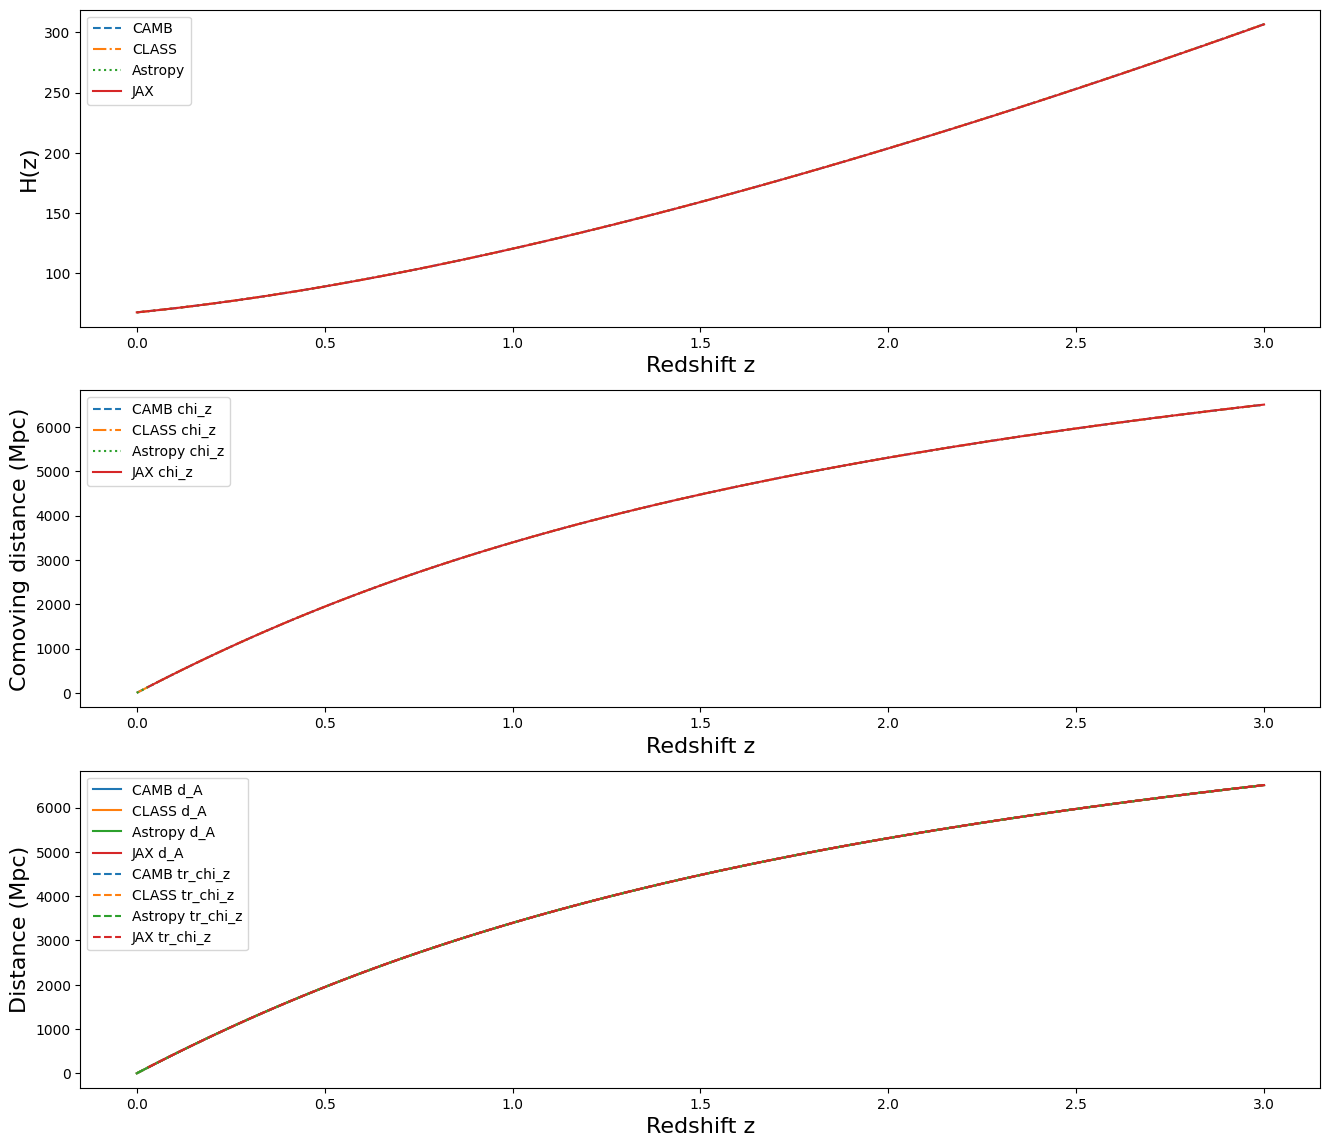

In [2]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
Omega_cdm0 = omch2/h**2
ombh2 = 0.022
Omega_b0 = ombh2/h**2
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.96
mnu = 0.
As=2e-9

# Astropy
Tcmb = 2.7255
Neff = 0.0#3.046
YHe = 0.2454

# z-array
z = np.linspace(0, 3, 100)

astropy_instance = FlatLambdaCDM(H0=H0,Om0=(Omega_cdm0 + Omega_b0),Ob0=Omega_b0, Tcmb0=Tcmb,Neff=Neff, m_nu=[0,0,0.0]*u.eV)
H_z_astropy = astropy_instance.H(z).to(u.km/u.s/u.Mpc).value
chi_z_astropy = astropy_instance.comoving_distance(z)
dA_z_astropy = astropy_instance.angular_diameter_distance(z)
tr_z_astropy = astropy_instance.comoving_transverse_distance(z)

camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0, N_mnu=0)
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')
chi_z_camb = camb_instance.comoving_distance(z)
dA_z_camb = camb_instance.angular_diameter_distance(z)
tr_z_camb = camb_instance.transverse_comoving_distance(z)

class_instance = CLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0, N_mnu=0)
H_z_class = class_instance.hubble_parameter(z)
chi_z_class = class_instance.comoving_distance(z)
dA_z_class = class_instance.angular_diameter_distance(z)
tr_z_class = class_instance.transverse_comoving_distance(z)

jax_instance = JAXBackground(H0=H0,Omega_b0=Omega_b0,Omega_cdm0=Omega_cdm0, 
                             Omega_k0=Omega_k0,
                             As=As, ns=ns, mnu=mnu, w0=w, wa=wa, gamma_MG=0., N_mnu=0)
H_z_jax = jax_instance.hubble_parameter(z)
chi_z_jax = jax_instance.comoving_distance(z)
dA_z_jax = jax_instance.angular_diameter_distance(z)
tr_z_jax = jax_instance.transverse_comoving_distance(z)

fig, axs = plt.subplots(figsize = (16,14), nrows=3, ncols=1)
axs[0].plot(z, H_z_camb, label = 'CAMB', ls='--')
axs[0].plot(z, H_z_class, label = 'CLASS', ls='-.')
axs[0].plot(z, H_z_astropy, label = 'Astropy', ls=':')
axs[0].plot(z, H_z_jax, label = 'JAX', ls='-')
axs[0].set_ylabel('H(z)', fontsize = 16)
axs[0].set_xlabel('Redshift z', fontsize = 16)
axs[0].legend()
axs[1].plot(z, chi_z_camb, label = 'CAMB chi_z', ls='--')
axs[1].plot(z, chi_z_class, label = 'CLASS chi_z', ls='-.')
axs[1].plot(z, chi_z_astropy, label = 'Astropy chi_z', ls=':')
axs[1].plot(z, chi_z_jax, label = 'JAX chi_z', ls='-')
axs[1].set_ylabel('Comoving distance (Mpc)', fontsize = 16)
axs[1].set_xlabel('Redshift z', fontsize = 16)
axs[1].legend()
axs[2].plot(z, dA_z_camb*(1+z), label = 'CAMB d_A', ls='-')
axs[2].plot(z, dA_z_class*(1+z), label = 'CLASS d_A', ls='-')
axs[2].plot(z, dA_z_astropy*(1+z), label = 'Astropy d_A', ls='-')
axs[2].plot(z, dA_z_jax*(1+z), label = 'JAX d_A', ls='-')
axs[2].set_ylabel('Distance (Mpc)', fontsize = 16)
plt.gca().set_prop_cycle(None)
axs[2].plot(z, tr_z_camb, label = 'CAMB tr_chi_z', ls='--')
axs[2].plot(z, tr_z_class, label = 'CLASS tr_chi_z', ls='--')
axs[2].plot(z, tr_z_astropy, label = 'Astropy tr_chi_z', ls='--')
axs[2].plot(z, tr_z_jax, label = 'JAX tr_chi_z', ls='--')
axs[2].set_xlabel('Redshift z', fontsize = 16)
axs[2].legend()

#Differences are due to neutrinos

In [3]:
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)

Text(0.5, 1.0, 'JAX Perturbations')

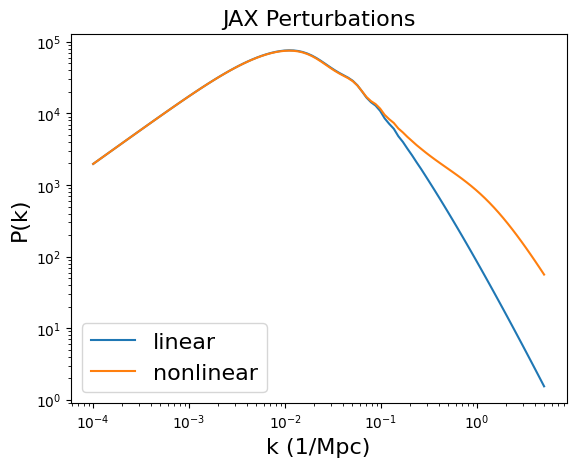

In [4]:
# JAX PERTURBATIONS
# k-array
jax_linear= JAXLinearPerturbations(background=jax_instance)
jax_nonlinear = JAXNonLinearPerturbations(background=jax_instance)
linear_pk_jax = jax_linear.matter_power_spectrum(z, ks)
nonlinear_pk_jax = jax_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_jax[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_jax[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("JAX Perturbations", fontsize = 16)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


Text(0.5, 1.0, 'CAMB Power Spectrum')

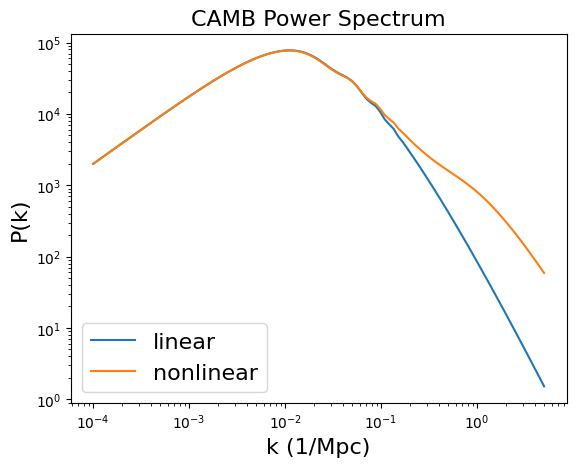

: 

In [5]:
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, 
                                            nonlinear_model='mead2016')

linear_pk_camb = camb_linear.matter_power_spectrum(z, ks)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_camb[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_camb[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB Power Spectrum", fontsize = 16)

Text(0.5, 1.0, 'CLASS Perturbations')

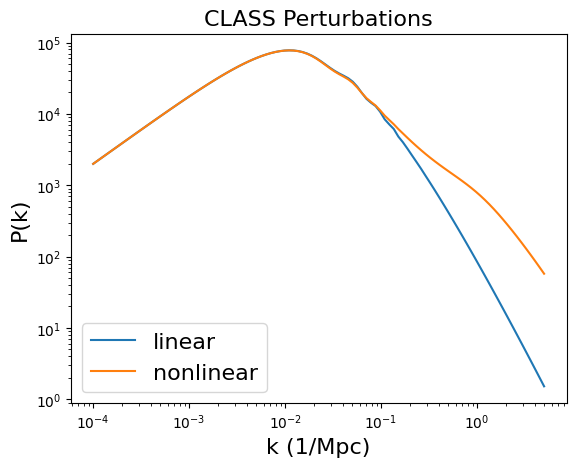

In [6]:
# CLASS PERTURBATIONS
# k-array
class_linear = CLASSLinearPerturbations(background=class_instance, redshifts=z)
class_nonlinear = CLASSNonLinearPerturbations(background=class_instance, 
                                              redshifts=z, 
                                              nonlinear_model='hmcode16')
linear_pk_class = class_linear.matter_power_spectrum(z, ks)
nonlinear_pk_class = class_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_class[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_class[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CLASS Perturbations", fontsize = 16)

Text(0.5, 1.0, 'CAMB vs. CLASS vs. JAX Linear Perturbations')

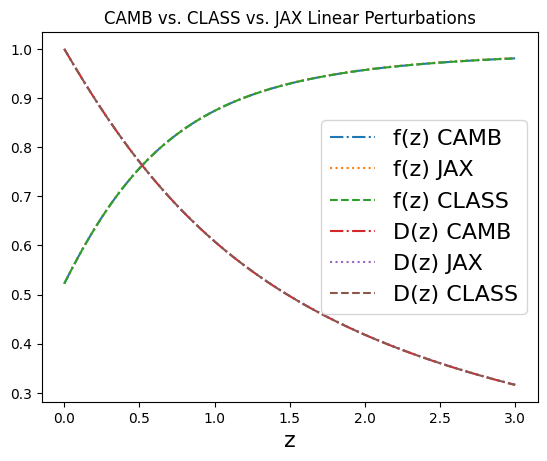

In [7]:
#calculate results for these parameters
plt.plot(z, camb_linear.growth_rate(), label = 'f(z) CAMB', ls='-.')
plt.plot(z, jax_linear.growth_rate(z), label = 'f(z) JAX', ls=':')
plt.plot(z, class_linear.growth_rate(), label = 'f(z) CLASS', ls='--')
plt.plot(z, camb_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CAMB', ls='-.')
plt.plot(z, jax_linear.growth_factor(z), label = 'D(z) JAX', ls=':')
plt.plot(z, class_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CLASS', ls='--')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB vs. CLASS vs. JAX Linear Perturbations")